In [1]:
# ============================================================
# COVID-19 Global Trends Analysis
# Author  : Udit Jadli
# Dataset : Kaggle - Corona Virus Report
# ============================================================


# ============================================================
# SECTION 1 - IMPORT LIBRARIES
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# System
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# SECTION 2 - LOAD DATA
# ============================================================

# Define file names
file_names = [
    'country_wise_latest',
    'covid_19_clean_complete',
    'day_wise',
    'full_grouped',
    'usa_county_wise',
    'worldometer_data'
]

# Files that contain a Date column with format
date_columns = {
    'covid_19_clean_complete' : ['Date'],
    'day_wise'                : ['Date'],
    'full_grouped'            : ['Date'],
    'usa_county_wise'         : ['Date']
}

# Loading all datasets with proper date parsing
datasets = {}
for name in file_names:
    df = pd.read_csv(f'../data/raw/{name}.csv')
    if name in date_columns:
        for col in date_columns[name]:
            df[col] = pd.to_datetime(df[col], format='mixed')
    datasets[name] = df

print("All datasets loaded successfully!\n")
for name, df in datasets.items():
    print(f" {name:<30} {df.shape[0]} rows x {df.shape[1]} columns")

All datasets loaded successfully!

 country_wise_latest            187 rows x 15 columns
 covid_19_clean_complete        49068 rows x 10 columns
 day_wise                       188 rows x 12 columns
 full_grouped                   35156 rows x 10 columns
 usa_county_wise                627920 rows x 14 columns
 worldometer_data               209 rows x 16 columns


In [3]:
# ============================================================
# SECTION 3 - DATA EXPLORATION
# ============================================================

# ---- 3.1 Preview First 5 Rows (Head) ----

for name, df in datasets.items():
    print(f"\n{'='*60}")  # Top border
    print(f"{name}")  # Dataset name
    print(f"{'='*60}")  # Bottom border
    print(df.head())
    print()

df.head(10)  # Preview first 10 rows of the last loaded dataset


country_wise_latest
  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04                35526  

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa
5,Mexico,North America,1.290662e+08,462690,6590.0,50517.0,819.0,308848.0,4140.0,103325.0,3987.0,3585.0,391.0,1056915.0,8189.0,Americas
6,Peru,South America,3.301632e+07,455409,NaN,20424.0,NaN,310337.0,NaN,124648.0,1426.0,13793.0,619.0,2493429.0,75521.0,Americas
7,Chile,South America,1.913251e+07,366671,NaN,9889.0,NaN,340168.0,NaN,16614.0,1358.0,19165.0,517.0,1760615.0,92022.0,Americas
8,Colombia,South America,5.093626e+07,357710,NaN,11939.0,NaN,192355.0,NaN,153416.0,1493.0,7023.0,234.0,1801835.0,35374.0,Americas
9,Spain,Europe,4.675665e+07,354530,NaN,28500.0,NaN,NaN,NaN,NaN,617.0,7582.0,610.0,7064329.0,151087.0,Europe


In [4]:
# ---- 3.2 Preview Last 5 Rows (Tail) ----

for name, df in datasets.items():
    print(f"\n{'='*60}")  # Top border
    print(f"{name}")  # Dataset name
    print(f"{'='*60}")  # Bottom border
    print(df.tail())
    print()

df.tail(10)  # Preview last 10 rows of the last loaded dataset


country_wise_latest
         Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
182  West Bank and Gaza      10621      78       3752    6791        152   
183      Western Sahara         10       1          8       1          0   
184               Yemen       1691     483        833     375         10   
185              Zambia       4552     140       2815    1597         71   
186            Zimbabwe       2704      36        542    2126        192   

     New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
182           2              0                0.73                  35.33   
183           0              0               10.00                  80.00   
184           4             36               28.56                  49.26   
185           1            465                3.08                  61.84   
186           2             24                1.33                  20.04   

     Deaths / 100 Recovered  Confirmed last week  1 week ch

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
199,New Caledonia,Australia/Oceania,285769.0,22,NaN,NaN,NaN,22.0,NaN,0.0,NaN,77.0,NaN,11099.0,38839.0,NaN
200,Laos,Asia,7285750.0,20,NaN,NaN,NaN,19.0,NaN,1.0,NaN,3.0,NaN,29374.0,4032.0,WesternPacific
201,Dominica,North America,72004.0,18,NaN,NaN,NaN,18.0,NaN,0.0,NaN,250.0,NaN,1005.0,13958.0,Americas
202,Saint Kitts and Nevis,North America,53237.0,17,NaN,NaN,NaN,16.0,NaN,1.0,NaN,319.0,NaN,1146.0,21526.0,Americas
203,Greenland,North America,56780.0,14,NaN,NaN,NaN,14.0,NaN,0.0,NaN,247.0,NaN,5977.0,105266.0,Europe
204,Montserrat,North America,4992.0,13,NaN,1.0,NaN,10.0,NaN,2.0,NaN,2604.0,200.0,61.0,12220.0,NaN
205,Caribbean Netherlands,North America,26247.0,13,NaN,NaN,NaN,7.0,NaN,6.0,NaN,495.0,NaN,424.0,16154.0,NaN
206,Falkland Islands,South America,3489.0,13,NaN,NaN,NaN,13.0,NaN,0.0,NaN,3726.0,NaN,1816.0,520493.0,NaN
207,Vatican City,Europe,801.0,12,NaN,NaN,NaN,12.0,NaN,0.0,NaN,14981.0,NaN,NaN,NaN,Europe
208,Western Sahara,Africa,598682.0,10,NaN,1.0,NaN,8.0,NaN,1.0,NaN,17.0,2.0,NaN,NaN,Africa


In [5]:
# ---- 3.3 Dataset Info ----

for name, df in datasets.items():
    print(f"\n{'='*60}")  # Top border
    print(f"{name}")  # Dataset name
    print(f"{'='*60}")  # Bottom border
    df.info() # Info of the last loaded dataset
    print()


country_wise_latest
<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    str    
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-

In [6]:
# ---- 3.4a Statistical Summary (Describe) ----

for name, df in datasets.items():
    print(f"\n{'='*60}")  # Top border
    print(f"{name}")  # Dataset name
    print(f"{'='*60}")  # Bottom border
    print(df.describe())
    print()


country_wise_latest
          Confirmed         Deaths     Recovered        Active     New cases  \
count  1.870000e+02     187.000000  1.870000e+02  1.870000e+02    187.000000   
mean   8.813094e+04    3497.518717  5.063148e+04  3.400194e+04   1222.957219   
std    3.833187e+05   14100.002482  1.901882e+05  2.133262e+05   5710.374790   
min    1.000000e+01       0.000000  0.000000e+00  0.000000e+00      0.000000   
25%    1.114000e+03      18.500000  6.265000e+02  1.415000e+02      4.000000   
50%    5.059000e+03     108.000000  2.815000e+03  1.600000e+03     49.000000   
75%    4.046050e+04     734.000000  2.260600e+04  9.149000e+03    419.500000   
max    4.290259e+06  148011.000000  1.846641e+06  2.816444e+06  56336.000000   

        New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
count   187.000000     187.000000          187.000000             187.000000   
mean     28.957219     933.812834            3.019519              64.820535   
std     120.037173

c:\Users\jadli\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


                UID          code3           FIPS            Lat  \
count  6.279200e+05  627920.000000  626040.000000  627920.000000   
mean   8.342958e+07     834.491617   33061.684685      36.707212   
min    1.600000e+01      16.000000      60.000000     -14.271000   
25%    8.401811e+07     840.000000   19079.000000      33.895587   
50%    8.402921e+07     840.000000   31014.000000      38.002344   
75%    8.404612e+07     840.000000   47131.000000      41.573069   
max    8.410000e+07     850.000000   99999.000000      69.314792   
std    4.314702e+06      36.492620   18636.156825       9.061572   

               Long_                        Date      Confirmed         Deaths  
count  627920.000000                      627920  627920.000000  627920.000000  
mean      -88.601474  2020-04-24 11:59:59.999999     357.284285      17.536328  
min      -174.159600         2020-01-22 00:00:00       0.000000       0.000000  
25%       -97.790204         2020-03-08 18:00:00       0.000000

In [7]:
# ---- 3.4b Statistical Summary for Text Columns ----

for name, df in datasets.items():
    print(f"\n{'='*60}")  # Top border
    print(f"{name}")   # Dataset name
    print(f"{'='*60}")    # Bottom border
    
    # Checking if dataset has any text columns before running describe
    text_cols = df.select_dtypes(include='object').columns
    
    if len(text_cols) == 0:
        print("No text columns found in this dataset!")
    else:
        # describe(include='O') shows summary for text/string columns only
        print(df.describe(include='O'))
    print()


country_wise_latest
       Country/Region WHO Region
count             187        187
unique            187          6
top       Afghanistan     Europe
freq                1         56


covid_19_clean_complete
                      Province/State Country/Region WHO Region
count                          14664          49068      49068
unique                            78            187          6
top     Australian Capital Territory          China     Europe
freq                             188           6204      15040


day_wise
No text columns found in this dataset!


full_grouped
       Country/Region WHO Region
count           35156      35156
unique            187          6
top       Afghanistan     Europe
freq              188      10528


usa_county_wise


C:\Users\jadli\AppData\Local\Temp\ipykernel_14364\1090714076.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include='object').columns
C:\Users\jadli\AppData\Local\Temp\ipykernel_14364\1090714076.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide

          iso2    iso3      Admin2 Province_State Country_Region  \
count   627920  627920      626792         627920         627920   
unique       6       6        1978             58              1   
top         US     USA  Unassigned          Texas             US   
freq    612128  612128        9776          48128         627920   

              Combined_Key  
count               627920  
unique                3340  
top     American Samoa, US  
freq                   188  


worldometer_data
       Country/Region Continent WHO Region
count             209       208        184
unique            209         6          6
top               USA    Africa     Europe
freq                1        57         55



C:\Users\jadli\AppData\Local\Temp\ipykernel_14364\1090714076.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include='object').columns
C:\Users\jadli\AppData\Local\Temp\ipykernel_14364\1090714076.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide

In [8]:
# ---- 3.5 Check Missing Values ----

for name, df in datasets.items():
    print(f"\n{'='*60}")  # Top border
    print(f"{name}")   # Dataset name
    print(f"{'='*60}")    # Bottom border
    
    # Count missing values per column
    print(df.isnull().sum())
    print()


country_wise_latest
Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64


covid_19_clean_complete
Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64


day_wise
Date                      0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Reco

In [9]:
# ---- 3.6 Check Duplicate Entries ----

for name, df in datasets.items():
    print(f"\n{'='*60}")  # Top border
    print(f"{name}")   # Dataset name
    print(f"{'='*60}")    # Bottom border
    
    # Count total duplicate rows in the dataset
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print()


country_wise_latest
Duplicate rows: 0


covid_19_clean_complete
Duplicate rows: 0


day_wise
Duplicate rows: 0


full_grouped
Duplicate rows: 0


usa_county_wise
Duplicate rows: 0


worldometer_data
Duplicate rows: 0



In [10]:
# ============================================================
# SECTION 4 - DATA CLEANING
# ============================================================

# ---- 4.1 Handle Missing Values ----

# First, let's check which datasets have missing values
for name, df in datasets.items():
    missing_total = df.isnull().sum().sum()  # Total missing values in dataset
    if missing_total > 0:
        print(f"\n{'='*60}")  # Top border
        print(f"{name}")   # Dataset name
        print(f"{'='*60}")    # Bottom border
        print(df.isnull().sum()[df.isnull().sum() > 0])  # This showscolumns with missing values only


covid_19_clean_complete
Province/State    34404
dtype: int64

usa_county_wise
FIPS      1880
Admin2    1128
dtype: int64

worldometer_data
Continent             1
Population            1
NewCases            205
TotalDeaths          21
NewDeaths           206
TotalRecovered        4
NewRecovered        206
ActiveCases           4
Serious,Critical     87
Tot Cases/1M pop      1
Deaths/1M pop        22
TotalTests           18
Tests/1M pop         18
WHO Region           25
dtype: int64


In [11]:
# ---- 4.1 Handle Missing Values ----

# --- covid_19_clean_complete ---
# Province/State is missing because not every country has province data
# Fill with 'Unknown' to indicate no province information available
datasets['covid_19_clean_complete']['Province/State'] = \
    datasets['covid_19_clean_complete']['Province/State'].fillna('Unknown')

# --- usa_county_wise ---
# Admin2 is county name - fill missing with 'Unknown'
datasets['usa_county_wise']['Admin2'] = \
    datasets['usa_county_wise']['Admin2'].fillna('Unknown')

# FIPS is a county code - not critical for our analysis, so we are leaving it as is

# --- worldometer_data ---
# Fill missing text columns with 'Unknown'
text_cols = ['Continent', 'WHO Region']
for col in text_cols:
    datasets['worldometer_data'][col] = \
        datasets['worldometer_data'][col].fillna('Unknown')

# Fill missing numerical columns with 0
num_cols = ['Population', 'NewCases', 'TotalDeaths', 'NewDeaths',
            'TotalRecovered', 'NewRecovered', 'ActiveCases',
            'Serious,Critical', 'Tot Cases/1M pop', 
            'Deaths/1M pop', 'TotalTests', 'Tests/1M pop']
for col in num_cols:
    datasets['worldometer_data'][col] = \
        datasets['worldometer_data'][col].fillna(0)

print("Missing values handled successfully!")

Missing values handled successfully!


In [12]:
# ---- Verifying if the missing Values are Fixed ----

for name, df in datasets.items():
    missing_total = df.isnull().sum().sum()  # Total missing values
    if missing_total > 0:
        print(f"{name} still has {missing_total} missing values!")
    else:
        print(f"{name} - No missing values!")

country_wise_latest - No missing values!
covid_19_clean_complete - No missing values!
day_wise - No missing values!
full_grouped - No missing values!
usa_county_wise still has 1880 missing values!
worldometer_data - No missing values!


In [13]:
# Check which column still has missing values in usa_county_wise
print(datasets['usa_county_wise'].isnull().sum()[datasets['usa_county_wise'].isnull().sum() > 0])

FIPS    1880
dtype: int64


In [14]:
# Drop FIPS column from usa_county_wise as it is not needed for our analysis
datasets['usa_county_wise'] = datasets['usa_county_wise'].drop(columns=['FIPS'])

print("FIPS column dropped from usa_county_wise!")

# Verifying if there is no more missing values
missing_total = datasets['usa_county_wise'].isnull().sum().sum()
print(f"   Missing values remaining: {missing_total}")

FIPS column dropped from usa_county_wise!
   Missing values remaining: 0


In [15]:
# ---- 4.2 Check Data Types ----

for name, df in datasets.items():
    print(f"\n{'='*60}")  # Top border
    print(f"{name}")   # Dataset name
    print(f"{'='*60}")    # Bottom border
    print(df.dtypes)
    print()


country_wise_latest
Country/Region                str
Confirmed                   int64
Deaths                      int64
Recovered                   int64
Active                      int64
New cases                   int64
New deaths                  int64
New recovered               int64
Deaths / 100 Cases        float64
Recovered / 100 Cases     float64
Deaths / 100 Recovered    float64
Confirmed last week         int64
1 week change               int64
1 week % increase         float64
WHO Region                    str
dtype: object


covid_19_clean_complete
Province/State               str
Country/Region               str
Lat                      float64
Long                     float64
Date              datetime64[us]
Confirmed                  int64
Deaths                     int64
Recovered                  int64
Active                     int64
WHO Region                   str
dtype: object


day_wise
Date                      datetime64[us]
Confirmed                        

In [16]:
# ---- 4.3 Save Cleaned Data ----

# Saving each cleaned dataset to the processed folder
for name, df in datasets.items():
    # Saving each dataset as a CSV file in the processed folder
    df.to_csv(f'../data/processed/{name}_cleaned.csv', index=False)
    print(f"{name}_cleaned.csv saved!")

print("\n All cleaned datasets saved to data/processed/!")

country_wise_latest_cleaned.csv saved!
covid_19_clean_complete_cleaned.csv saved!
day_wise_cleaned.csv saved!
full_grouped_cleaned.csv saved!
usa_county_wise_cleaned.csv saved!
worldometer_data_cleaned.csv saved!

 All cleaned datasets saved to data/processed/!


In [17]:
# ============================================================
# SECTION 5 - ANALYSIS & VISUALS
# ============================================================

# ---- 5.1 Global Overview ----

# We will use day_wise, as this shows global totals by date.
# For this we will use .iloc[-1] to get the most recent totals from the last row of day_wise dataset.
latest = datasets['day_wise'].iloc[-1]

# Extract total numbers
total_confirmed = latest['Confirmed']
total_deaths    = latest['Deaths']
total_recovered = latest['Recovered']

# Calculate rates

# This tells us what % of confirmed cases resulted in death
death_rate    = round((total_deaths / total_confirmed) * 100, 2)

# This tells us what % of confirmed cases recovered successfully
recovery_rate = round((total_recovered / total_confirmed) * 100, 2)

# Print the global summary
# "=" This means the character we want to repeat
# *45 This means repeat it 45 times
# This will print a horizontal line like this: ===============================================
print("="*45)
print("       COVID-19 GLOBAL OVERVIEW")
print("="*45)
print(f"  Total Confirmed  : {total_confirmed:,}")
print(f"  Total Deaths     : {total_deaths:,}")
print(f"  Total Recovered  : {total_recovered:,}")
print(f"  Death Rate       : {death_rate}%")
print(f"  Recovery Rate    : {recovery_rate}%")
print("="*45)

       COVID-19 GLOBAL OVERVIEW
  Total Confirmed  : 16,480,485
  Total Deaths     : 654,036
  Total Recovered  : 9,468,087
  Death Rate       : 3.97%
  Recovery Rate    : 57.45%


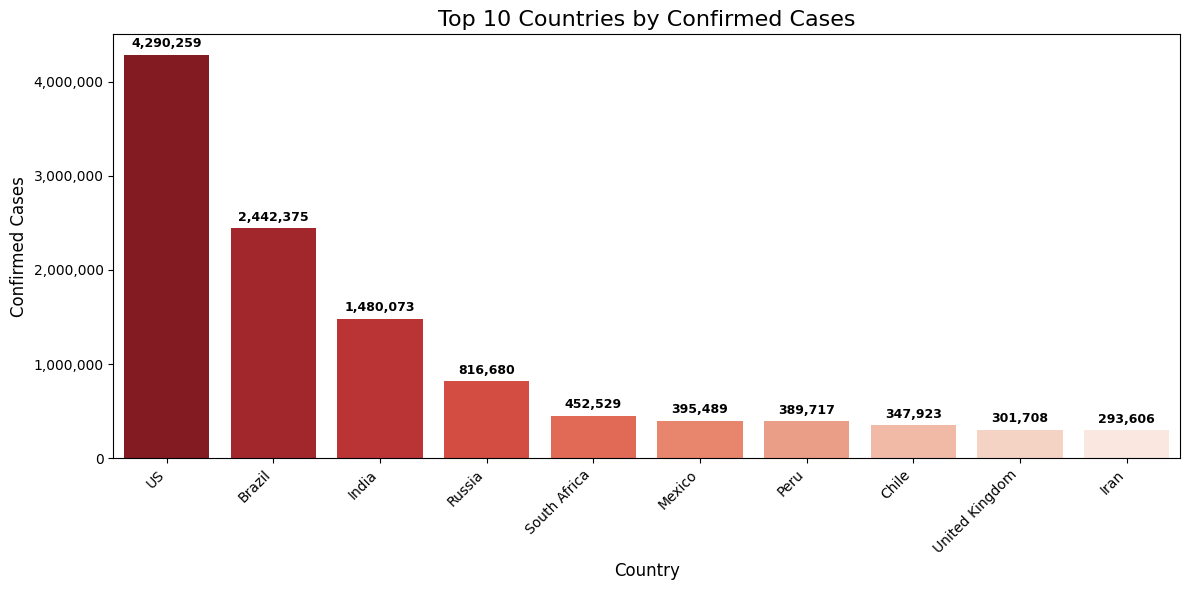

In [18]:
# ---- 5.2 Top 10 Countries by Confirmed Cases ----

# Top 10 countries with highest confirmed cases
# nlargest(10, 'Confirmed') - This means that we get 10 rows with largest Confirmed values
top10_confirmed = datasets['country_wise_latest'].nlargest(10, 'Confirmed')

# Creating the bar chart
plt.figure(figsize=(12, 6))  # Set the size of the chart (width=12, height=6)

# Draw the bar chart
# x axis = country names, y axis = confirmed cases
# palette = color theme of the bars
sns.barplot(
    data    = top10_confirmed,
    x       = 'Country/Region',
    y       = 'Confirmed',
    hue     = 'Country/Region',  # Added to fix FutureWarning
    palette = 'Reds_r',
    legend  = False              # Hide legend as it is not needed
)

# Adding numbers on top of each bar
for i, row in enumerate(top10_confirmed.itertuples()):
    # Formatting the number with commas and placing it on top of each bar
    plt.text(
        i,                              # x position - bar number
        row.Confirmed + 50000,          # y position - slightly above the bar
        f'{row.Confirmed:,}',           # number formatted with commas
        ha     = 'center',              # aligning text to center of bar
        va     = 'bottom',              # placing text at the bottom of the position
        fontsize = 9,                   # font size
        fontweight = 'bold'             # making it bold so it stands out
    )

# Add title and axis labels
plt.title('Top 10 Countries by Confirmed Cases', fontsize=16)  # Chart title
plt.xlabel('Country', fontsize=12)                             # X axis label
plt.ylabel('Confirmed Cases', fontsize=12)                     # Y axis label

# Rotate x axis labels so country names don't overlap
plt.xticks(rotation=45, ha='right')

# Add comma formatting to y axis numbers for readability
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ','))
)

# Adjust layout so nothing gets cut off
plt.tight_layout()

# Display the chart
plt.show()

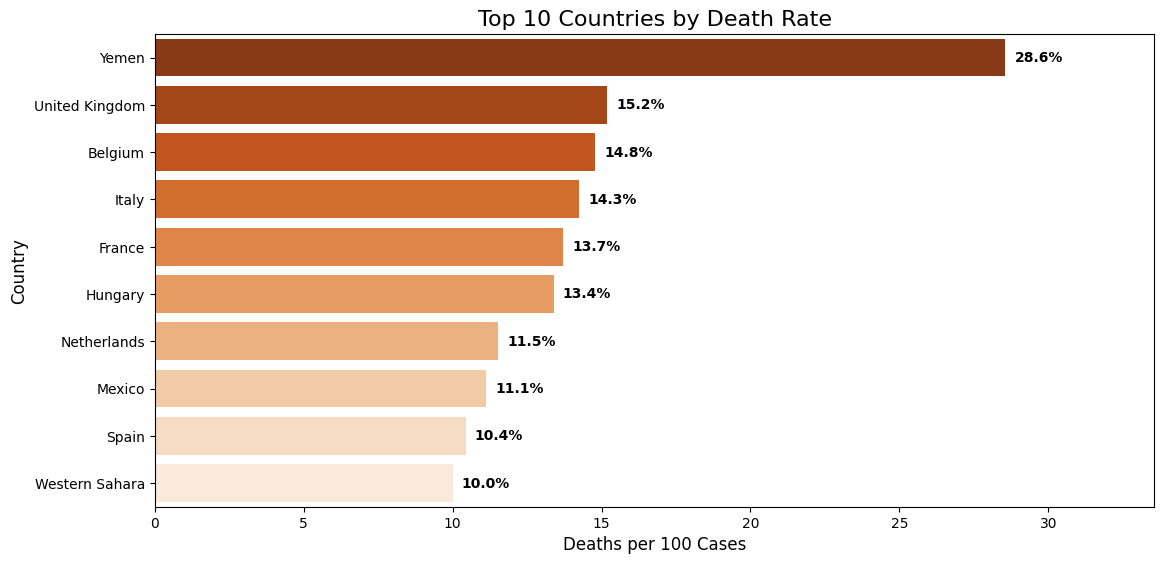

In [19]:
# ---- 5.3a Top 10 Countries by Death Rate - Horizontal Bar Chart ----
# Used for: clear ranking comparison between countries
# Best for: showing which country ranks higher/lower at a glance

# Get top 10 countries with highest death rate
top10_death_rate = datasets['country_wise_latest'].nlargest(10, 'Deaths / 100 Cases')

# Reset index so we can access rows easily
top10_death_rate = top10_death_rate.reset_index(drop=True)

# Create the chart - made wider to fit numbers at the end of bars
plt.figure(figsize=(12, 6))

# Draw horizontal bar chart
ax = sns.barplot(
    data    = top10_death_rate,
    x       = 'Deaths / 100 Cases',
    y       = 'Country/Region',
    hue     = 'Country/Region',  # Added to fix FutureWarning
    palette = 'Oranges_r',
    legend  = False              # Hide legend as it is not needed
)

# Add numbers at the end of each horizontal bar
for i in range(len(top10_death_rate)):
    # Get the death rate value directly from the dataframe using row index
    value = top10_death_rate.loc[i, 'Deaths / 100 Cases']
    ax.text(
        value + 0.3,         # x position - slightly after the end of the bar
        i,                    # y position - bar number
        f'{value:.1f}%',      # number formatted to 1 decimal place with % sign
        ha       = 'left',    # aligning text to left of position
        va       = 'center',  # aligning text to the centre of the bar height
        fontsize = 10,        # font size
        fontweight = 'bold'   # making it bold so it stands out
    )

# Add title and axis labels
plt.title('Top 10 Countries by Death Rate', fontsize=16)
plt.xlabel('Deaths per 100 Cases', fontsize=12)
plt.ylabel('Country', fontsize=12)

# Add extra space on the right so numbers don't get cut off
plt.xlim(0, top10_death_rate['Deaths / 100 Cases'].max() + 5)

# Adjust layout so nothing gets cut off
plt.tight_layout(pad=2.0)

# Display the chart
plt.show()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


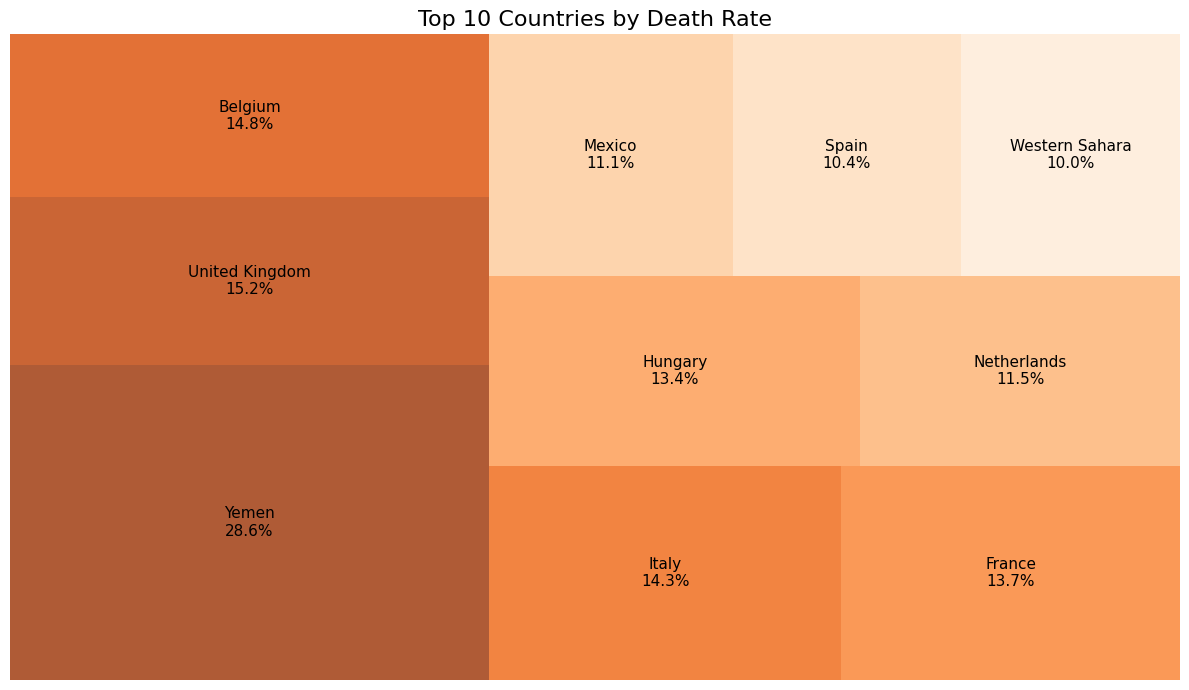

In [20]:
# ---- 5.3b Top 10 Countries by Death Rate - Treemap ----
# Used for: showing proportional differences visually
# Best for: understanding how much larger Yemen's death rate is vs others

# ... treemap code ...

# Install squarify library - this is needed to create Treemap charts
%pip install squarify 
import squarify

# Get top 10 countries with highest death rate
top10_death_rate = datasets['country_wise_latest'].nlargest(10, 'Deaths / 100 Cases')

# Create the chart
plt.figure(figsize=(12, 7))  # Set the size of the chart

# Draw the treemap
# sizes = the values that determine rectangle size
# label = text shown inside each rectangle
squarify.plot(
    sizes  = top10_death_rate['Deaths / 100 Cases'],  # Rectangle size = death rate
    label  = [f"{c}\n{d:.1f}%" for c, d in zip(
                top10_death_rate['Country/Region'],
                top10_death_rate['Deaths / 100 Cases'])],  # Label = country + rate
    color  = sns.color_palette('Oranges_r', 10),  # Same orange color theme
    alpha  = 0.8,                                  # Slight transparency
    text_kwargs = {'fontsize': 11}                 # Font size of labels
)

# Add title
plt.title('Top 10 Countries by Death Rate', fontsize=16)

# Remove axes as treemaps don't need them
plt.axis('off')

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

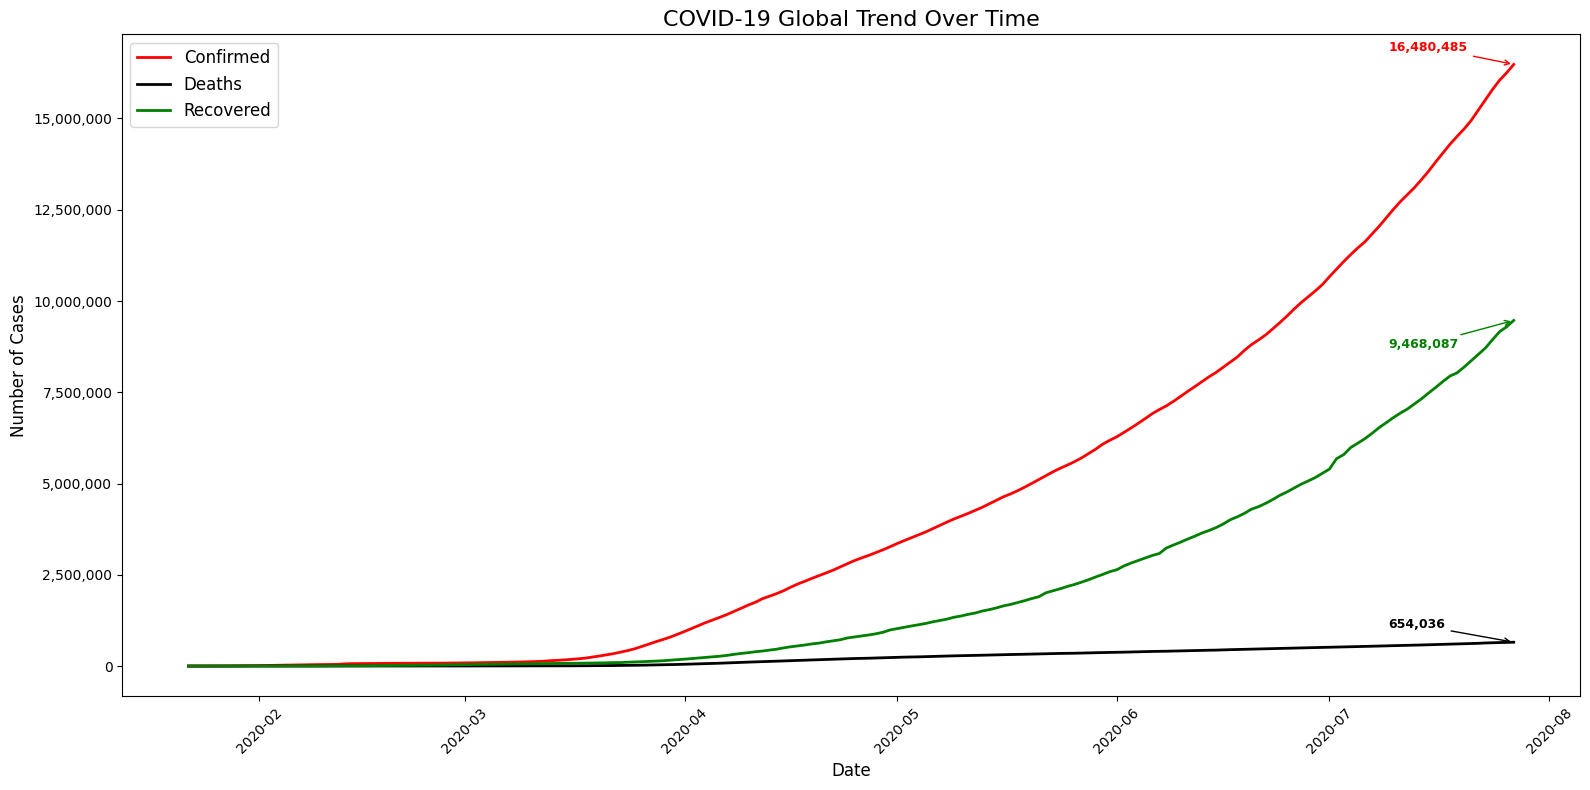

In [21]:
# ---- 5.4 Global Trend Over Time ----
# Line chart showing how confirmed, deaths and recovered changed over time
# Best for: understanding the progression and growth of the pandemic globally

# Using day_wise dataset which has daily global totals
day_wise = datasets['day_wise']

# Get the last row which has the most recent values
# iloc[-1] means get the last row
last_row = day_wise.iloc[-1]

# Create the chart
plt.figure(figsize=(16, 8))  

# Plot confirmed cases line in red
plt.plot(day_wise['Date'], day_wise['Confirmed'],
         color='red', linewidth=2, label='Confirmed')

# Plot deaths line in black
plt.plot(day_wise['Date'], day_wise['Deaths'],
         color='black', linewidth=2, label='Deaths')

# Plot recovered line in green
plt.plot(day_wise['Date'], day_wise['Recovered'],
         color='green', linewidth=2, label='Recovered')

# Add final value label at the end of Confirmed line
plt.annotate(
    f'{last_row["Confirmed"]:,}',        # show final confirmed value
    xy         = (last_row['Date'], last_row['Confirmed']),  # end of line
    xytext     = (-90, 10),              # offset text slightly above
    textcoords = 'offset points',
    fontsize   = 9,
    fontweight = 'bold',
    color      = 'red',
    arrowprops = dict(arrowstyle='->', color='red')
)

# Add final value label at the end of Deaths line
plt.annotate(
    f'{last_row["Deaths"]:,}',           # show final deaths value
    xy         = (last_row['Date'], last_row['Deaths']),
    xytext     = (-90, 10),
    textcoords = 'offset points',
    fontsize   = 9,
    fontweight = 'bold',
    color      = 'black',
    arrowprops = dict(arrowstyle='->', color='black')
)

# Add final value label at the end of Recovered line
plt.annotate(
    f'{last_row["Recovered"]:,}',        # show final recovered value
    xy         = (last_row['Date'], last_row['Recovered']),
    xytext     = (-90, -20),
    textcoords = 'offset points',
    fontsize   = 9,
    fontweight = 'bold',
    color      = 'green',
    arrowprops = dict(arrowstyle='->', color='green')
)

# Add title and axis labels
plt.title('COVID-19 Global Trend Over Time', fontsize=16)  # Chart title
plt.xlabel('Date', fontsize=12)                            # X axis label
plt.ylabel('Number of Cases', fontsize=12)                 # Y axis label

# Add legend so we know which line is which
plt.legend(fontsize=12)

# Add comma formatting to y axis numbers for readability
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ','))
)

# Rotate x axis dates so they don't overlap
plt.xticks(rotation=45)

# Adjust layout so nothing gets cut off
plt.tight_layout()

# Display the chart
plt.show()

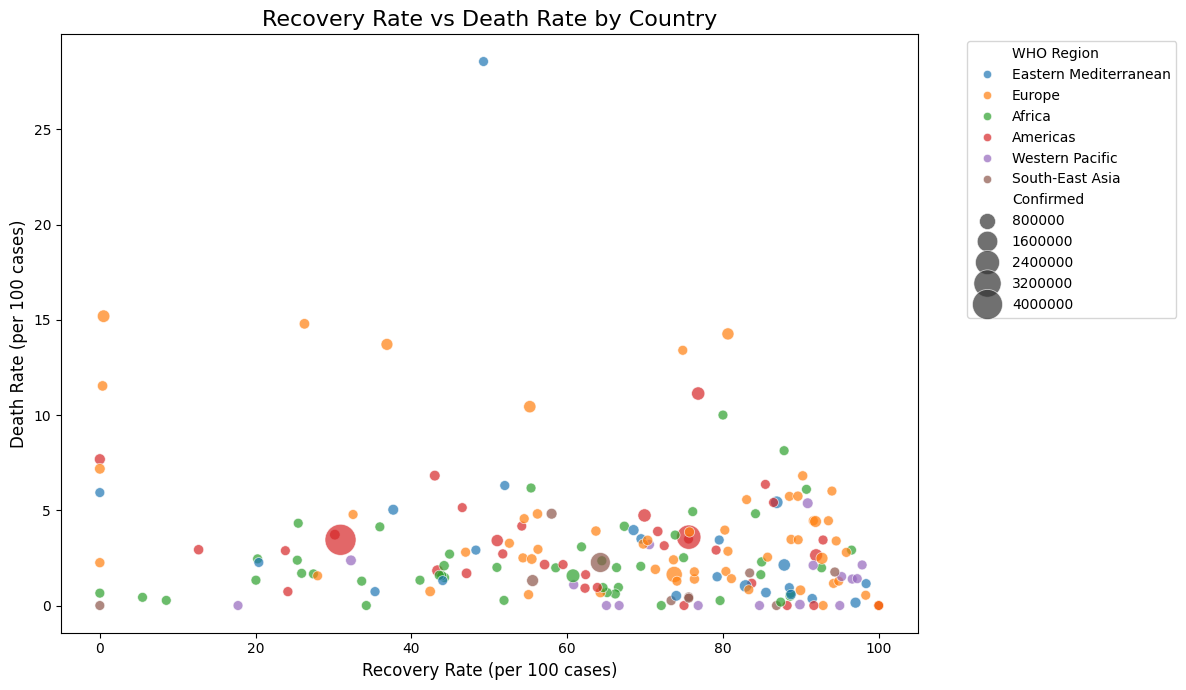

In [22]:
# ---- 5.5 Recovery Rate vs Death Rate by Country ----
# Scatter plot showing relationship between recovery rate and death rate
# Each dot represents one country
# Best for: identifying outlier countries and understanding the relationship between the two rates

# Use country_wise_latest dataset
country_wise = datasets['country_wise_latest']

# Create the chart
plt.figure(figsize=(12, 7))  # Set the size of the chart

# Draw the scatter plot
# x axis = recovery rate, y axis = death rate
# hue = color each dot by WHO Region so we can see regional patterns
sns.scatterplot(
    data    = country_wise,
    x       = 'Recovered / 100 Cases',  # Recovery rate on x axis
    y       = 'Deaths / 100 Cases',      # Death rate on y axis
    hue     = 'WHO Region',              # Color by WHO Region
    size    = 'Confirmed',               # Bigger dot = more confirmed cases
    sizes   = (50, 500),                 # Min and max dot size
    alpha   = 0.7                        # Slight transparency so dots don't overlap
)

# Add title and axis labels
plt.title('Recovery Rate vs Death Rate by Country', fontsize=16)  # Chart title
plt.xlabel('Recovery Rate (per 100 cases)', fontsize=12)          # X axis label
plt.ylabel('Death Rate (per 100 cases)', fontsize=12)             # Y axis label

# Move legend outside the chart so it doesn't block the dots
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Adjust layout so nothing gets cut off
plt.tight_layout()

# Display the chart
plt.show()

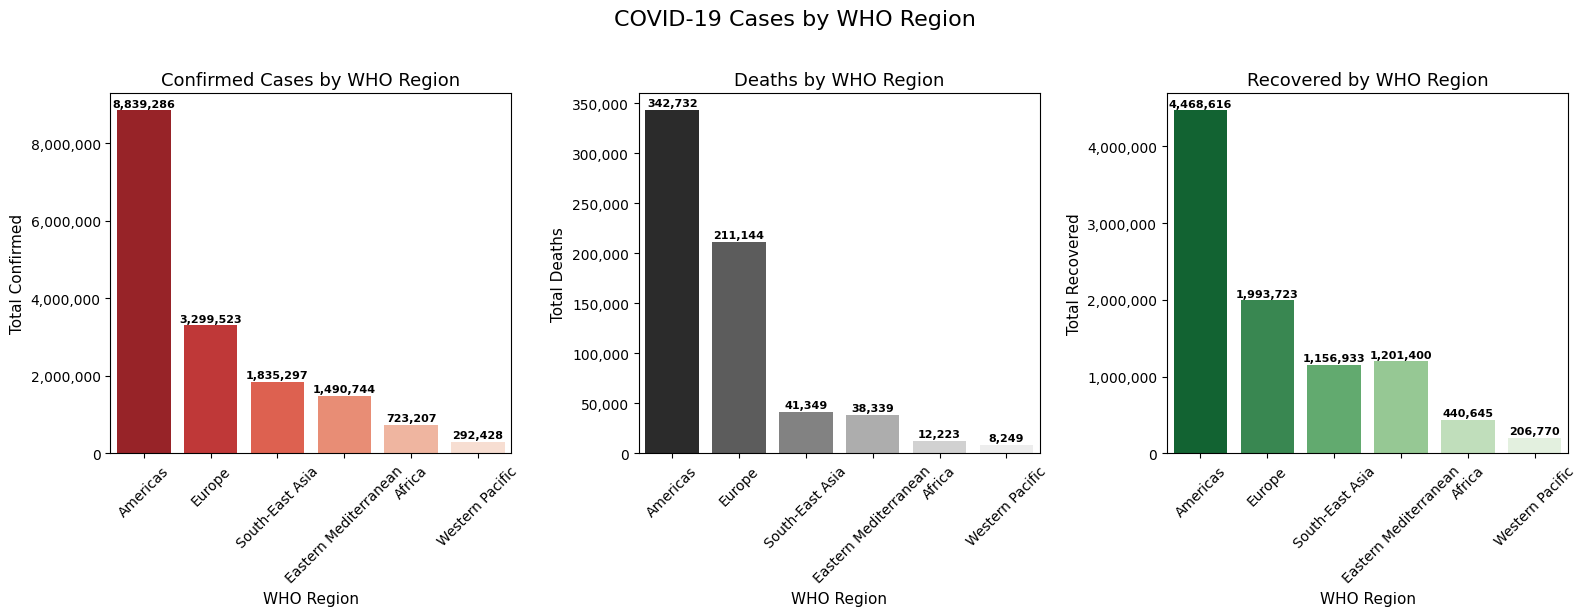

In [23]:
# ---- 5.6 Cases by WHO Region ----
# Bar chart showing total confirmed, deaths and recovered by WHO Region
# Best for: comparing how different regions were affected by COVID-19

# Group country_wise_latest by WHO Region and sum up the numbers
region_data = datasets['country_wise_latest'].groupby('WHO Region')[
    ['Confirmed', 'Deaths', 'Recovered']
].sum().reset_index()

# Sort by confirmed cases so highest region appears first
# reset_index so we can access rows by position using loc
region_data = region_data.sort_values('Confirmed', ascending=False).reset_index(drop=True)

# Create the chart - 3 side by side charts
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ---- Chart 1: Confirmed Cases by Region ----
ax1 = sns.barplot(
    data    = region_data,
    x       = 'WHO Region',
    y       = 'Confirmed',
    hue     = 'WHO Region',  # Added to fix FutureWarning
    palette = 'Reds_r',
    legend  = False,          # Hide legend as it is not needed
    ax      = axes[0]         # Place in first subplot
)
# Add numbers on top of each bar
for i in range(len(region_data)):
    value = region_data.loc[i, 'Confirmed']
    ax1.text(
        i,              # x position - bar number
        value + 50000,  # y position - slightly above the bar
        f'{value:,}',   # number formatted with commas
        ha         = 'center',  # center align text
        va         = 'bottom',  # place at bottom of position
        fontsize   = 8,         # font size
        fontweight = 'bold'     # bold so it stands out
    )
axes[0].set_title('Confirmed Cases by WHO Region', fontsize=13)
axes[0].set_xlabel('WHO Region', fontsize=11)
axes[0].set_ylabel('Total Confirmed', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ','))
)

# ---- Chart 2: Deaths by Region ----
ax2 = sns.barplot(
    data    = region_data,
    x       = 'WHO Region',
    y       = 'Deaths',
    hue     = 'WHO Region',  # Added to fix FutureWarning
    palette = 'Greys_r',
    legend  = False,          # Hide legend as it is not needed
    ax      = axes[1]         # Place in second subplot
)
# Add numbers on top of each bar
for i in range(len(region_data)):
    value = region_data.loc[i, 'Deaths']
    ax2.text(
        i,             # x position - bar number
        value + 2000,  # y position - slightly above the bar
        f'{value:,}',  # number formatted with commas
        ha         = 'center',
        va         = 'bottom',
        fontsize   = 8,
        fontweight = 'bold'
    )
axes[1].set_title('Deaths by WHO Region', fontsize=13)
axes[1].set_xlabel('WHO Region', fontsize=11)
axes[1].set_ylabel('Total Deaths', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ','))
)

# ---- Chart 3: Recovered by Region ----
ax3 = sns.barplot(
    data    = region_data,
    x       = 'WHO Region',
    y       = 'Recovered',
    hue     = 'WHO Region',  # Added to fix FutureWarning
    palette = 'Greens_r',
    legend  = False,          # Hide legend as it is not needed
    ax      = axes[2]         # Place in third subplot
)
# Add numbers on top of each bar
for i in range(len(region_data)):
    value = region_data.loc[i, 'Recovered']
    ax3.text(
        i,             # x position - bar number
        value + 20000, # y position - slightly above the bar
        f'{value:,}',  # number formatted with commas
        ha         = 'center',
        va         = 'bottom',
        fontsize   = 8,
        fontweight = 'bold'
    )
axes[2].set_title('Recovered by WHO Region', fontsize=13)
axes[2].set_xlabel('WHO Region', fontsize=11)
axes[2].set_ylabel('Total Recovered', fontsize=11)
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ','))
)

# Add main title for all 3 charts
plt.suptitle('COVID-19 Cases by WHO Region', fontsize=16, y=1.02)

# Adjust layout so nothing gets cut off
plt.tight_layout()

# Display the chart
plt.show()